In [2]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
import pandas as pd
import matplotlib as plt
import json
import random
import sys
from pathlib import Path
import numpy as np
import subprocess
import sys
from sentence_transformers import SentenceTransformer

2.13.0+cu130
13.0
True
NVIDIA GeForce RTX 3060 Laptop GPU


By: Faadil A. Shaikh


In collaboration with InceptionAI

In [3]:
current_dir = Path.cwd().resolve()
WORKSPACE_ROOT = next(
    (candidate for candidate in (current_dir, *current_dir.parents)
     if (candidate / "Temporal-Testing").is_dir() and (candidate / "Fin-RATE").is_dir()),
    None,
)
if WORKSPACE_ROOT is None:
    raise FileNotFoundError("Could not locate the Inception workspace from the notebook directory.")
TEMPORAL_TESTING_DIR = WORKSPACE_ROOT / "Temporal-Testing"
if str(TEMPORAL_TESTING_DIR) not in sys.path:
    sys.path.insert(0, str(TEMPORAL_TESTING_DIR))

from reproducibility import DEFAULT_SEED, seed_everything
SEED = DEFAULT_SEED
seed_everything(SEED)

42

In [4]:
with (WORKSPACE_ROOT / "Fin-RATE" / "qa" / "LT-QA.json").open("r", encoding="utf-8") as file:
    ltqa = json.load(file)

In [5]:
print(ltqa[1].keys())
print(ltqa[1]["key_points"])

dict_keys(['question', 'answer', 'doc_ids', 'key_points', 'q_id'])
['The strategic initiatives were continuations of the long-term transformation strategy established after the sale of the retail solutions business in fiscal 2014', 'The company maintained an exclusive focus on the hospitality industry during this period', 'A key strategic initiative was to increase revenue proportion from subscription services, cloud applications, support/maintenance, and professional services', "The strategy centered on providing state-of-the-art, end-to-end, integrated 'platform-centric' solutions to enhance guest experiences and improve operational efficiency", 'No new major strategic shifts or pivots were reported specifically for the 2019-2020 period']


In [11]:
nqa = 150
question_sampler = random.Random(SEED)
smoke_test_ltqa = question_sampler.sample(ltqa, nqa)
sample_docs = set()
for sample_qa in smoke_test_ltqa:
    docs = set(sample_qa["doc_ids"])
    sample_docs.update(docs)

print(len(smoke_test_ltqa))
print(len(sample_docs))

subset_questions_path = TEMPORAL_TESTING_DIR / "ltqa_subset_questions_ex.json"
subset_questions_path.write_text(
    json.dumps(smoke_test_ltqa, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

subset_doc_ids_path = TEMPORAL_TESTING_DIR / "ltqa_subset_doc_ids_ex.json"
subset_doc_ids_path.write_text(
    json.dumps(sorted(sample_docs), ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"Saved {len(smoke_test_ltqa)} LT-QA records to {subset_questions_path}")
print(f"Saved {len(sample_docs)} connected document IDs to {subset_doc_ids_path}")


150
276
Saved 150 LT-QA records to C:\Users\hello2\Documents\Inception\Temporal-Testing\ltqa_subset_questions_ex.json
Saved 276 connected document IDs to C:\Users\hello2\Documents\Inception\Temporal-Testing\ltqa_subset_doc_ids_ex.json


In [16]:
nqa = 100
question_sampler = random.Random(SEED)
smoke_test_ltqa = question_sampler.sample(ltqa, nqa)
sample_docs = set()
for sample_qa in smoke_test_ltqa:
    docs = set(sample_qa["doc_ids"])
    sample_docs.update(docs)

print(len(smoke_test_ltqa))
print(len(sample_docs))


100
218


<Axes: >

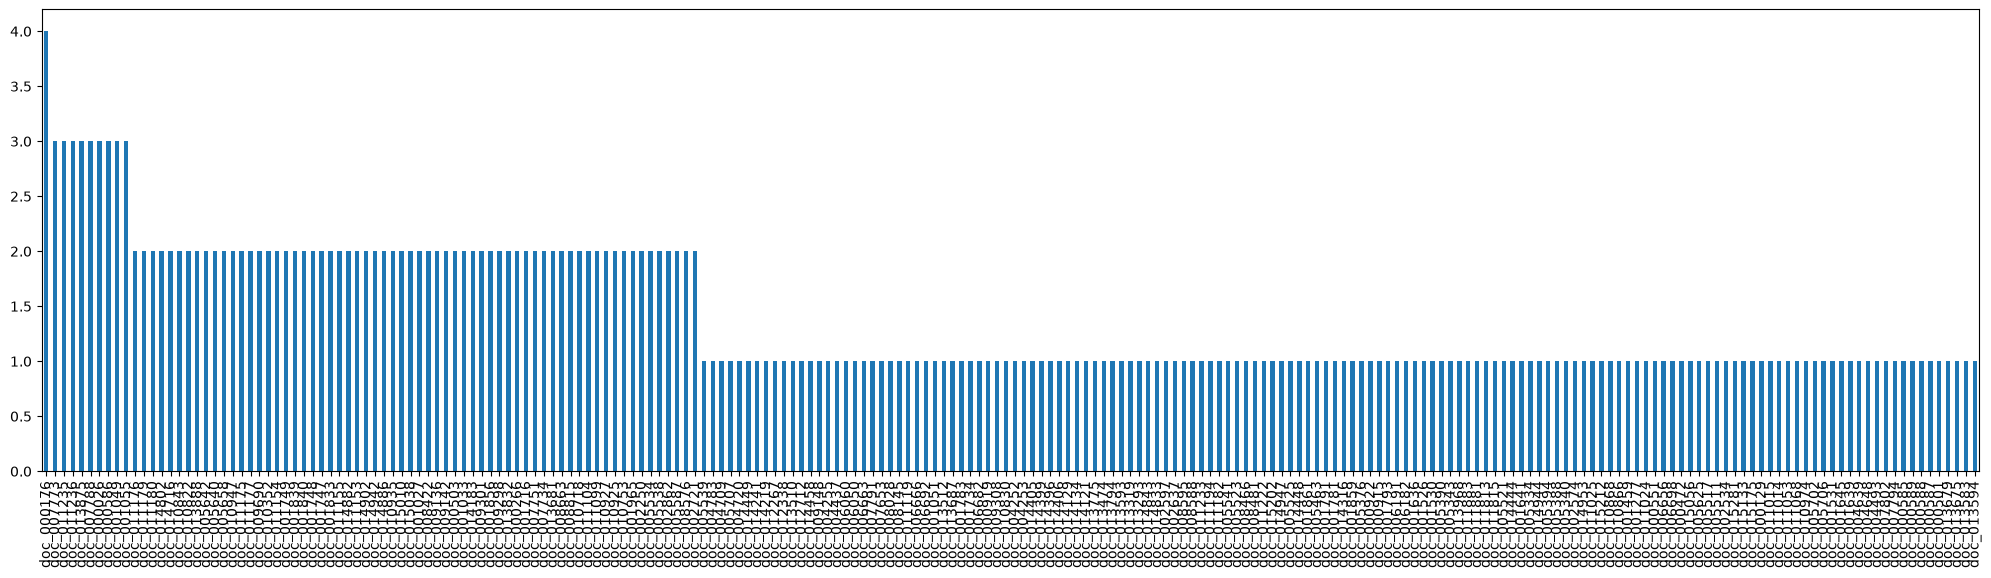

In [17]:
doc_freq = {}
for sample_qa in smoke_test_ltqa:
    for docid in sample_qa["doc_ids"]:
        if docid in doc_freq.keys():
            doc_freq[docid] += 1
        else:
            doc_freq[docid] = 1
pd.Series(doc_freq).sort_values(ascending=False).plot.bar(figsize=(25, 6))

<Axes: >

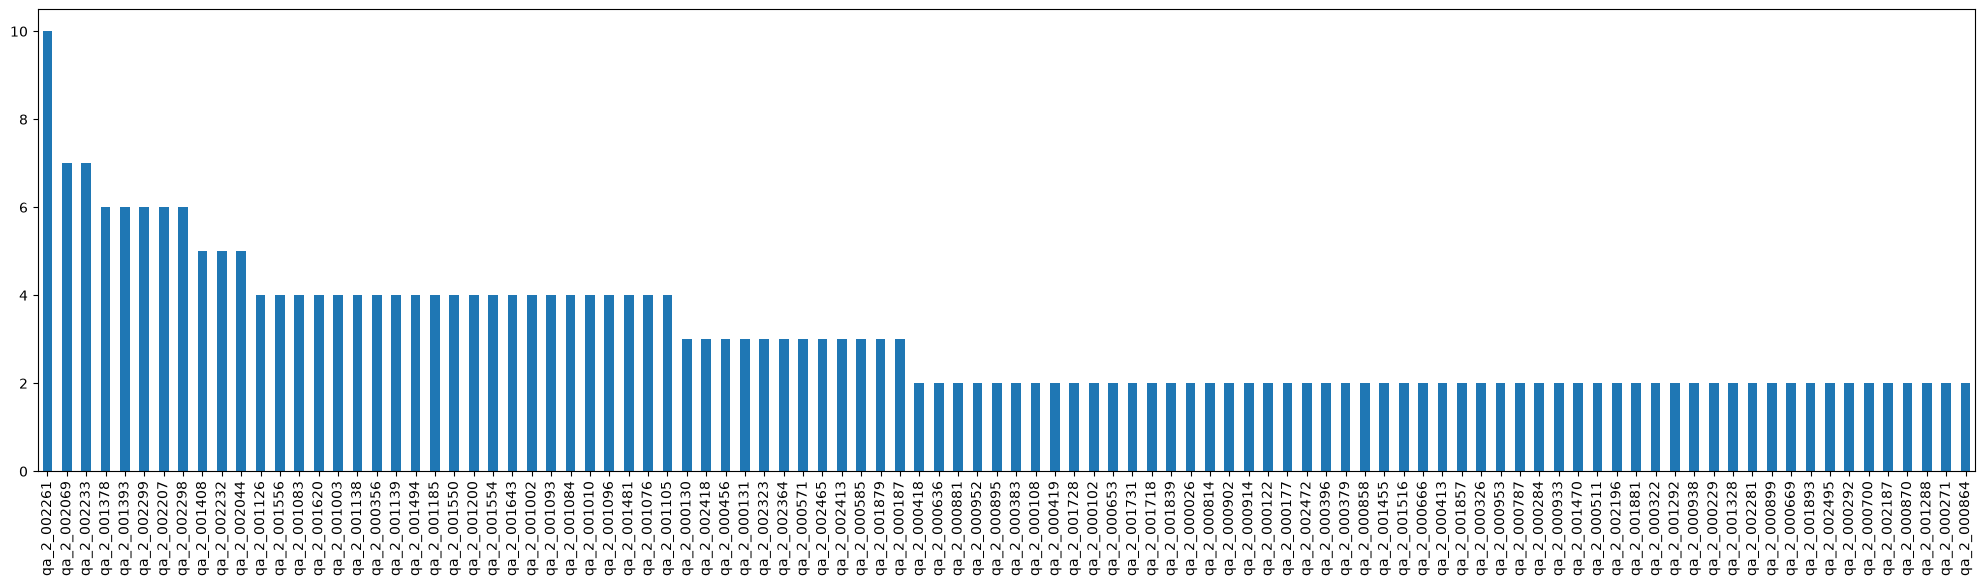

In [19]:
que_freq = {}
for sample_qa in smoke_test_ltqa:
    que_freq[sample_qa["q_id"]] = len(sample_qa["doc_ids"])
pd.Series(que_freq).sort_values(ascending=False).plot.bar(figsize=(25, 6))

<Axes: >

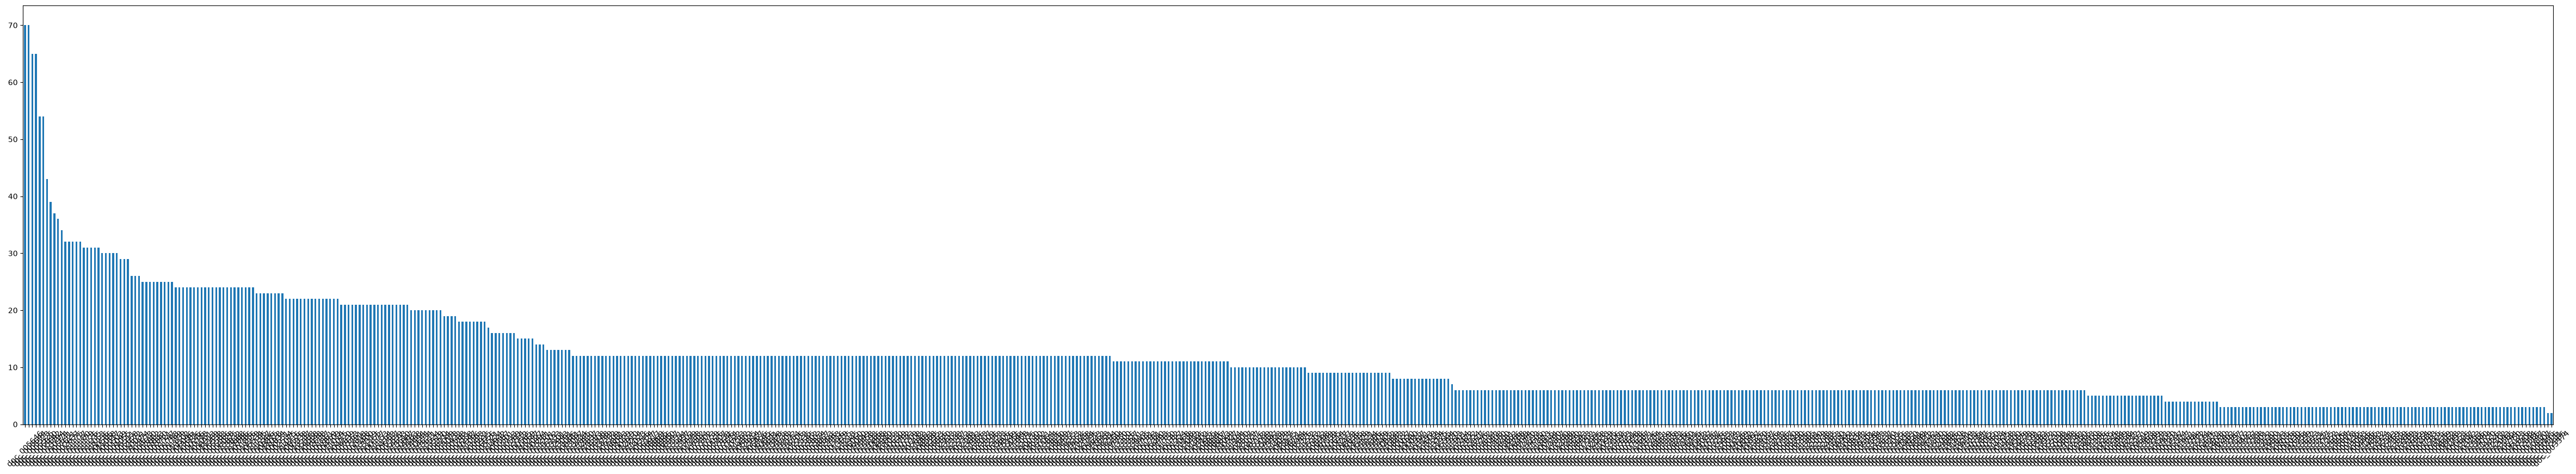

In [23]:
doc_freq = {}
for sample_qa in ltqa:
    for docid in sample_qa["doc_ids"]:
        if docid in doc_freq.keys():
            doc_freq[docid] += 1
        else:
            doc_freq[docid] = 1
pd.Series(doc_freq).sort_values(ascending=False).plot.bar(figsize=(60, 10),rot=45)

<Axes: >

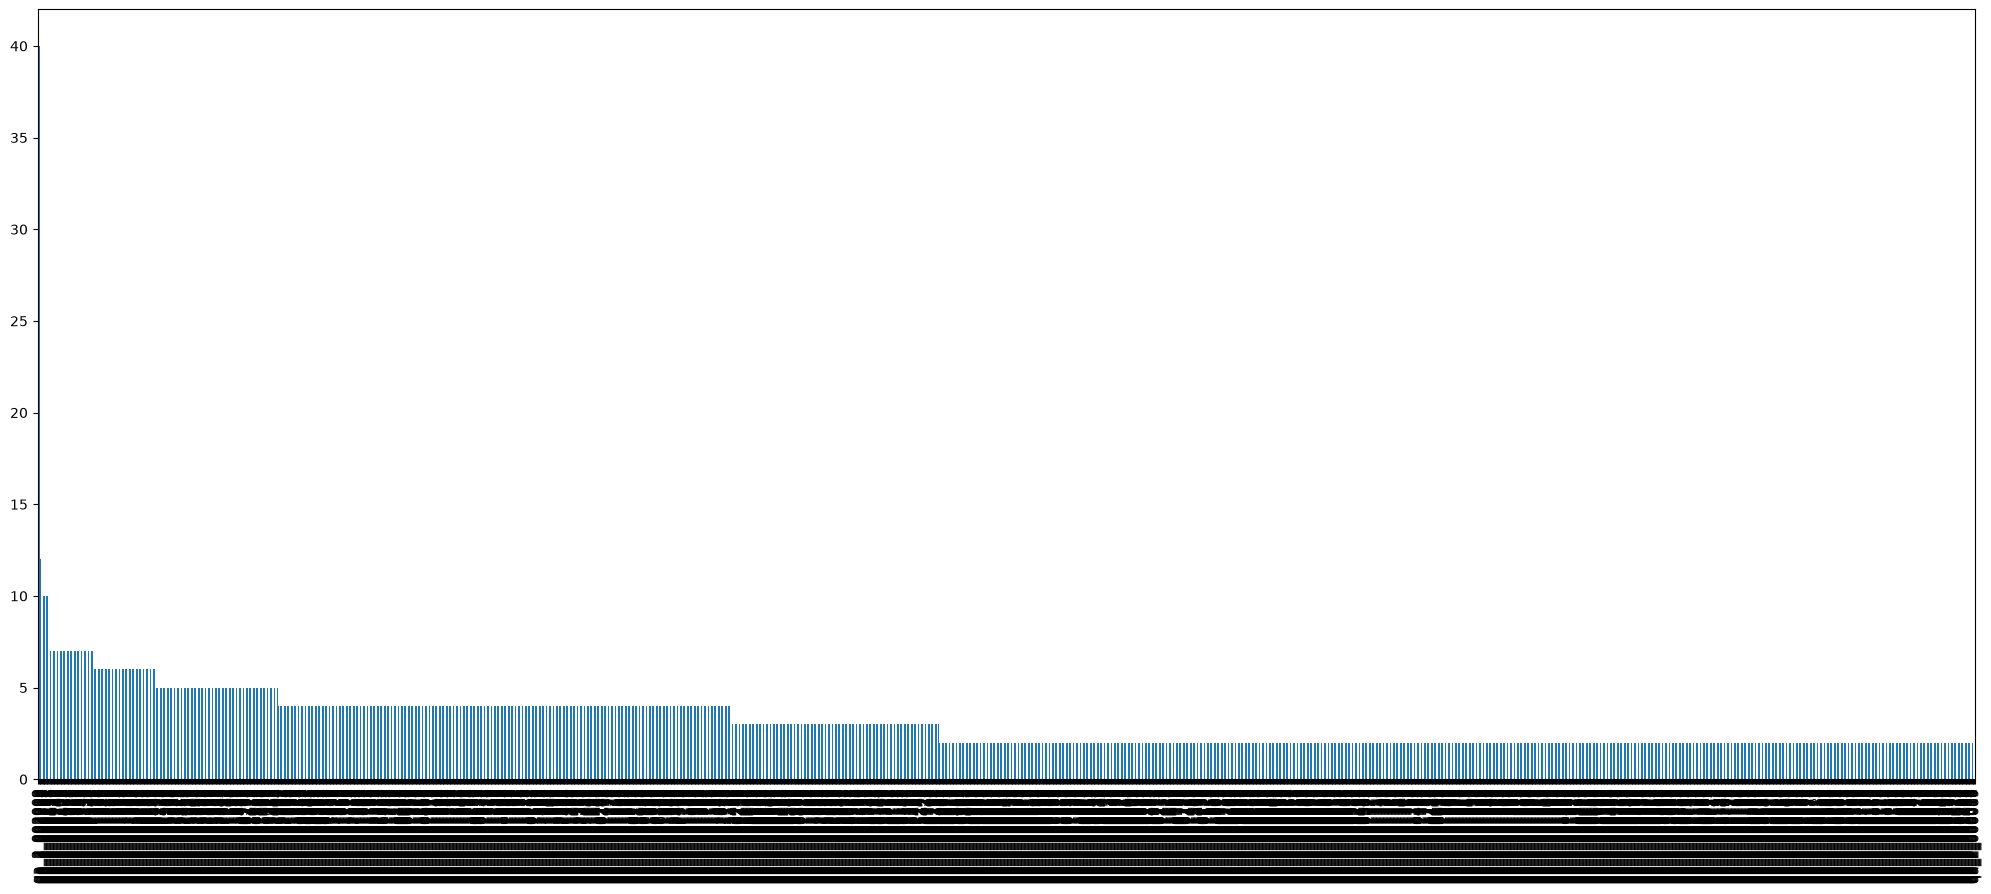

In [22]:
que_freq = {}
for sample_qa in ltqa:
    que_freq[sample_qa["q_id"]] = len(sample_qa["doc_ids"])
pd.Series(que_freq).sort_values(ascending=False).plot.bar(figsize=(25, 10))

In [29]:
print(np.median(list(que_freq.values())))
print(np.mean(list(que_freq.values())))

2.0
3.0944


In [31]:
huge_sample = []
for qa in ltqa:
    if set(qa["doc_ids"]).issubset(set(sample_docs)):
        huge_sample.append(qa)

In [36]:
subset_questions_path = TEMPORAL_TESTING_DIR / "ltqa_subset_questions_big.json"
subset_questions_path.write_text(
    json.dumps(huge_sample, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

2152918

# Base Chroma and ChromaMetaData Build and Benchmark

In [ ]:
from ChromaSetup import build_chroma_database as build_plain_chroma
from ChromaSetupMetaData import (
    build_chroma_database as build_metadata_chroma,
    create_embedding_function,
)

embedding_function = create_embedding_function(
    backend="ollama",
    model_name="embeddinggemma:latest",
    ollama_embedding_batch_size=32,
    seed=SEED,
)

'''
plain_stats = build_plain_chroma(
    document_ids=sorted(sample_docs),
    db_dir=WORKSPACE_ROOT / "Fin-RATE" / "chroma_db_ltqa_subset",
    collection_name="fin_rate_ltqa_subset_ex",
    embedding_function=embedding_function,
    batch_size=256,
    seed=SEED,
)
'''

metadata_stats = build_metadata_chroma(
    document_ids=sorted(sample_docs),
    db_dir=WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset_ex",
    collection_name="fin_rate_ltqa_subset_ex",
    embedding_function=embedding_function,
    seed=SEED,
)

#print("Plain Chroma:", plain_stats["build_seconds"], "seconds")
print("Metadata Chroma:", metadata_stats["build_seconds"], "seconds")


Metadata Chroma: 678.9398081999971 seconds


In [ ]:
benchmark_command = [
    sys.executable,
    str(TEMPORAL_TESTING_DIR / "benchmark_retrievers.py"),
    "--systems", "chroma,chroma_metadata",
    "--qa-file", str(TEMPORAL_TESTING_DIR / "ltqa_subset_questions.json"),
    "--chroma-db-dir", str(WORKSPACE_ROOT / "Fin-RATE" / "chroma_db_ltqa_subset"),
    "--chroma-metadata-db-dir", str(
        WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset_ex"
    ),
    "--chroma-collection", "fin_rate_ltqa_subset",
    "--embedding-backend", "ollama",
    "--embedding-model", "embeddinggemma:latest",
    "--metadata-filter-mode", "ollama",
    "--metadata-llm-model", "qwen3:4b",
    "--ollama-url", "http://127.0.0.1:11434",
    "--warmup", "0",
]

subprocess.run(
    benchmark_command,
    cwd=TEMPORAL_TESTING_DIR,
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--systems', 'chroma,chroma_metadata', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions.json', '--chroma-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_db_ltqa_subset', '--chroma-metadata-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_metadata_db_ltqa_subset', '--chroma-collection', 'fin_rate_ltqa_subset', '--embedding-backend', 'ollama', '--embedding-model', 'embeddinggemma:latest', '--metadata-filter-mode', 'ollama', '--metadata-llm-model', 'qwen3:4b', '--ollama-url', 'http://127.0.0.1:11434', '--warmup', '0'], returncode=0)

# Base Engram and EngramMetaData Build and Benchmark

In [7]:
from Engram_Temporal import (
    OllamaEmbedder,
    OllamaLLM,
    _service_namespace_dir,
    build_store,
)

temporal_namespace = "fin-rate-ltqa-subset_ex"
temporal_data_dir = WORKSPACE_ROOT / "Fin-RATE" / "engram_data_ltqa_subset_ex"
temporal_store_dir = _service_namespace_dir(
    temporal_data_dir,
    temporal_namespace,
)

llm = OllamaLLM(
    "qwen3:4b",
    base_url="http://127.0.0.1:11434",
    timeout=300,
    num_ctx=4096,
    num_predict=768,
    seed=SEED,
)

embedder = OllamaEmbedder(
    "embeddinggemma:latest",
    base_url="http://127.0.0.1:11434",
    timeout=300,
)


In [8]:
import importlib
import Engram_Temporal
importlib.reload(Engram_Temporal)

from Engram_Temporal import OllamaLLM, OllamaEmbedder, build_store

llm = OllamaLLM(
    "qwen3:4b",
    base_url="http://127.0.0.1:11434",
    num_ctx=4096,
    num_predict=768,
)

embedder = OllamaEmbedder(
    "embeddinggemma:latest",
    base_url="http://127.0.0.1:11434",
)

In [9]:
import importlib
import Engram_Temporal
importlib.reload(Engram_Temporal)

<module 'Engram_Temporal' from 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\Engram_Temporal.py'>

In [10]:
engram_stats = build_store(
    corpus_path=WORKSPACE_ROOT / "Fin-RATE" / "corpus" / "corpus" / "corpus.jsonl",
    store_dir=temporal_store_dir,
    namespace=temporal_namespace,
    document_ids=sorted(sample_docs),
    limit=None,
    chunk_size_tokens=512,
    chunk_overlap_tokens=64,
    reset=True,

    # Deterministic chunk summaries; avoids one Qwen call per chunk.
    summarize=True,
    llm_summaries=False,

    # Temporal enrichment and broad-question navigation.
    llm_document_metadata=True,
    filing_summaries=True,
    llm_filing_summaries=True,

    # Current temporal query path retrieves raw chunks, not extracted text facts.
    extract_text_facts=False,
    deep_relationships=True,

    llm=llm,
    embedder=embedder,
    metadata_llm_text_chars=4000,
    filing_summary_input_chars=12000,
    seed=SEED,
)

print(engram_stats)
print("Temporal Engram store:", temporal_store_dir)

#WILL TAKE ABOUT 90 to 150 minutes to RUN


[Engram build] starting raw document ingestion
[Engram build] completed document ingestion progress (25 new docs, 0 resumed docs, 657 chunks, 609 metadata facts)
[Engram build] completed document ingestion progress (50 new docs, 0 resumed docs, 1055 chunks, 1176 metadata facts)
[Engram build] completed document ingestion progress (75 new docs, 0 resumed docs, 1420 chunks, 1787 metadata facts)
[Engram build] completed document ingestion progress (100 new docs, 0 resumed docs, 2011 chunks, 2417 metadata facts)
[Engram build] completed document ingestion progress (125 new docs, 0 resumed docs, 2485 chunks, 3021 metadata facts)
[Engram build] completed document ingestion progress (150 new docs, 0 resumed docs, 2843 chunks, 3617 metadata facts)
[Engram build] completed document ingestion progress (175 new docs, 0 resumed docs, 3751 chunks, 4268 metadata facts)
[Engram build] completed document ingestion progress (200 new docs, 0 resumed docs, 4423 chunks, 4886 metadata facts)
[Engram build]

In [12]:
from pathlib import Path
import importlib
import Engram_Base
importlib.reload(Engram_Base)

from Engram_Base import build_store, OllamaEmbedder, load_document_ids_file

TEMPORAL_TESTING_DIR = WORKSPACE_ROOT / "Temporal-Testing"
subset_document_ids = load_document_ids_file(
    TEMPORAL_TESTING_DIR / "ltqa_subset_doc_ids.json"
)

regular_store_dir = WORKSPACE_ROOT / "Fin-RATE" / "engram_data_regular_ltqa_subset"
regular_namespace = "fin-rate-regular-ltqa-subset"

regular_embedder = OllamaEmbedder(
    "embeddinggemma:latest",
    base_url="http://127.0.0.1:11434",
    timeout=300,
)

regular_engram_stats = build_store(
    corpus_path=WORKSPACE_ROOT / "Fin-RATE" / "corpus" / "corpus" / "corpus.jsonl",
    store_dir=regular_store_dir,
    namespace=regular_namespace,
    limit=None,
    document_ids=subset_document_ids,
    chunk_size_tokens=512,
    chunk_overlap_tokens=64,
    reset=True,
    summarize=True,
    extract_text_facts=False,
    deep_relationships=True,
    llm=None,
    embedder=regular_embedder,
    llm_summaries=False,
)

regular_engram_stats

{'corpus_path': 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\corpus\\corpus\\corpus.jsonl',
 'store_dir': 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\engram_data_regular_ltqa_subset',
 'namespace': 'fin-rate-regular-ltqa-subset',
 'documents_seen': 218,
 'document_ids_filter': ['doc_000026',
  'doc_000129',
  'doc_000176',
  'doc_000266',
  'doc_000472',
  'doc_000501',
  'doc_000503',
  'doc_000551',
  'doc_000585',
  'doc_000586',
  'doc_000587',
  'doc_000588',
  'doc_000589',
  'doc_000915',
  'doc_000919',
  'doc_000922',
  'doc_001027',
  'doc_001033',
  'doc_001049',
  'doc_001051',
  'doc_001055',
  'doc_001277',
  'doc_001459',
  'doc_001526',
  'doc_001530',
  'doc_001531',
  'doc_001636',
  'doc_001639',
  'doc_001641',
  'doc_001645',
  'doc_001716',
  'doc_001734',
  'doc_001747',
  'doc_001748',
  'doc_001749',
  'doc_001781',
  'doc_001783',
  'doc_001791',
  'doc_001793',
  'doc_001833',
  'doc_001839',
  'doc_001840',
  'doc_001856',
  'doc_001859',
  'd

In [6]:
from ChromaSetupMetaData import build_chroma_database,create_embedding_function
embd = create_embedding_function(backend="ollama",model_name="embeddinggemma",device="cuda")


In [6]:
build_chroma_database(
    document_ids=list(sample_docs),
    collection_name="fin_rate_mini",
    embedding_function=embd
)

{'corpus_path': 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\corpus\\corpus\\corpus.jsonl',
 'database_dir': 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_db',
 'collection_name': 'fin_rate_mini',
 'records_read': 15039,
 'documents_seen': 125,
 'document_ids_filter': ['doc_000026',
  'doc_000176',
  'doc_000266',
  'doc_000503',
  'doc_000586',
  'doc_000915',
  'doc_000919',
  'doc_000922',
  'doc_001027',
  'doc_001033',
  'doc_001049',
  'doc_001051',
  'doc_001055',
  'doc_001716',
  'doc_001734',
  'doc_001747',
  'doc_001748',
  'doc_001749',
  'doc_001781',
  'doc_001783',
  'doc_001791',
  'doc_001793',
  'doc_001833',
  'doc_001839',
  'doc_001840',
  'doc_001856',
  'doc_001859',
  'doc_001861',
  'doc_002597',
  'doc_002637',
  'doc_004252',
  'doc_004253',
  'doc_004255',
  'doc_004437',
  'doc_004709',
  'doc_004720',
  'doc_004783',
  'doc_005376',
  'doc_005463',
  'doc_005539',
  'doc_005640',
  'doc_005642',
  'doc_005658',
  'doc_005707',
  'doc_0

In [7]:
smoke_test_ltqa[1]["question"]

"What progress has BeiGene's cornerstone product BRUKINSA made in global market coverage from 2022 to 2023? How has the description of its leadership position in the Chinese BTK inhibitor market changed?"

In [8]:
from ChromaSetupMetaData import answer_question
result = answer_question(
    question=smoke_test_ltqa[1]["question"],
    collection_name="fin_rate_mini",
    embedding_function=embd,
    n_results=5,
    llm_model="qwen3:4b",
)

In [26]:
smoke_test_ltqa[1]["doc_ids"]

['doc_013510', 'doc_013681']

In [ ]:
[chun["id"] for chun in result["chunks"]]

['doc_013510::chunk_0002',
 'doc_013593::chunk_0003',
 'doc_013510::chunk_0014',
 'doc_013794::chunk_0063',
 'doc_013681::chunk_0006']

In [24]:
[docid[:10] for docid in [chun["id"] for chun in result["chunks"]]]

['doc_013510', 'doc_013593', 'doc_013510', 'doc_013794', 'doc_013681']

In [18]:
print(smoke_test_ltqa[1]["answer"])
print("\n___________________________________________\n")
print(result["answer"])

In terms of market coverage, BRUKINSA was already 'approved in >65 markets' in 2022. The 2023 summary continued the statement of being 'approved in more than 65 markets,' indicating that its global coverage network has reached a stable and broad stage in terms of numbers, with the focus potentially shifting from开拓新市场 to deepening penetration and growth in already approved markets. Regarding the description of its leadership position in the Chinese market, the 2022 summary explicitly stated that BRUKINSA was the 'market leader in China for BTKi class.' The 2023 summary, while not repeating the exact same phrase, emphasized that BRUKINSA is the 'first and only BTK inhibitor to demonstrate superior efficacy versus ibrutinib in R/R CLL,' which is the key clinical cornerstone of its market leadership. Combined with its remarkable sales growth of 128.5% in 2023, it can be inferred that its market leadership position has been consolidated and strengthened.

___________________________________

# Benchmarks

In [ ]:


TEMPORAL_TESTING_DIR = WORKSPACE_ROOT / "Temporal-Testing"

benchmark_command = [
    sys.executable,
    str(TEMPORAL_TESTING_DIR / "benchmark_retrievers.py"),

    "--systems", "chroma,chroma_metadata,engram_base,engram_temporal",
    "--qa-file", str(TEMPORAL_TESTING_DIR / "ltqa_subset_questions.json"),
    "--warmup", "1",
    "--n-results", "15",

    "--chroma-db-dir",
    str(WORKSPACE_ROOT / "Fin-RATE" / "chroma_db_ltqa_subset"),
    "--chroma-metadata-db-dir",
    str(WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset"),
    "--chroma-collection", "fin_rate_ltqa_subset",
    "--embedding-backend", "ollama",
    "--embedding-model", "embeddinggemma:latest",
    "--metadata-filter-mode", "heuristic",

    "--engram-base-store-dir",
    str(WORKSPACE_ROOT / "Fin-RATE" / "engram_data_regular_ltqa_subset"),
    "--engram-base-namespace", "fin-rate-regular-ltqa-subset",

    "--engram-temporal-store-dir",
    str(
        WORKSPACE_ROOT / "Fin-RATE" / "engram_data_ltqa_subset"
        / "fin-rate-ltqa-subset--9caea23b52b2bd9b"
    ),
    "--engram-temporal-namespace", "fin-rate-ltqa-subset",
    "--engram-ollama-embed-model", "embeddinggemma:latest",

    "--output-dir",
    str(WORKSPACE_ROOT / "Fin-RATE" / "retrieval_benchmarks"),
    "--output-prefix", "ltqa_subset_four_systems",
]

subprocess.run(
    benchmark_command,
    cwd=TEMPORAL_TESTING_DIR,
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--systems', 'chroma,chroma_metadata,engram_base,engram_temporal', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions.json', '--warmup', '1', '--n-results', '15', '--chroma-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_db_ltqa_subset', '--chroma-metadata-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_metadata_db_ltqa_subset', '--chroma-collection', 'fin_rate_ltqa_subset', '--embedding-backend', 'ollama', '--embedding-model', 'embeddinggemma:latest', '--metadata-filter-mode', 'heuristic', '--engram-base-store-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\engram_data_regular_ltqa_subset', '--engram-base-namespace', 'fin-rate-regular-ltqa-subset', '--engram-temporal-store-dir', 'C:\\Users\\hello2\\Documents\

# **VARIATION BENCHMARK TESTING**

In [19]:
from pathlib import Path
import subprocess
import sys

benchmark_script = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
#qa_file = WORKSPACE_ROOT / "Fin-RATE" / "qa" / "LT-QA.json"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "ltqa_subset_questions.json"

common_args = [
    "--systems", "engram_temporal",
    "--qa-file", str(qa_file),
    "--limit", "100",
    "--n-results", "15",
    "--top-ks", "5,10,15",
    "--engram-ollama-embed-model", "embeddinggemma:latest",
]

# Original metadata-only Temporal Engram
'''
subprocess.run(
    [
        sys.executable, str(benchmark_script),
        *common_args,
        "--output-prefix", "ltqa_temporal_original",
    ],
    check=True,
)
'''

# New query-time company-alias resolver
subprocess.run(
    [
        sys.executable, str(benchmark_script),
        *common_args,
        "--temporal-llm-query-time-company-resolver",
        "--temporal-llm-model", "qwen3:4b",
        "--output-prefix", "ltqa_temporal_LLM_Aliases",
    ],
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--systems', 'engram_temporal', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions.json', '--limit', '100', '--n-results', '15', '--top-ks', '5,10,15', '--engram-ollama-embed-model', 'embeddinggemma:latest', '--temporal-llm-query-time-company-resolver', '--temporal-llm-model', 'qwen3:4b', '--output-prefix', 'ltqa_temporal_LLM_Aliases'], returncode=0)

In [28]:
script = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "ltqa_subset_questions.json"


chroma_metadata_dir = (
    WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset"
)

subprocess.run(
    [
        sys.executable,
        str(script),
        "--answer-comparison",
        "--qa-file", str(qa_file),
        "--answer-sample-size", "20",
        "--n-results", "15",
        "--seed", "42",
        "--chroma-metadata-db-dir", str(chroma_metadata_dir),
        "--chroma-collection", "fin_rate_ltqa_subset",
        "--answer-model", "qwen3:4b-instruct",
        "--temporal-llm-model", "qwen3:4b-instruct",
        "--engram-ollama-embed-model", "embeddinggemma:latest",
        "--embedding-backend", "ollama",
        "--embedding-model", "embeddinggemma:latest",
        "--metadata-filter-mode", "heuristic",
        "--answer-output-prefix", "ltqa_20_answer_comparison_4b_instruct",
    ],
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--answer-comparison', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions.json', '--answer-sample-size', '20', '--n-results', '15', '--seed', '42', '--chroma-metadata-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_metadata_db_ltqa_subset', '--chroma-collection', 'fin_rate_ltqa_subset', '--answer-model', 'qwen3:4b-instruct', '--temporal-llm-model', 'qwen3:4b-instruct', '--engram-ollama-embed-model', 'embeddinggemma:latest', '--embedding-backend', 'ollama', '--embedding-model', 'embeddinggemma:latest', '--metadata-filter-mode', 'heuristic', '--answer-output-prefix', 'ltqa_20_answer_comparison_4b_instruct'], returncode=0)

In [30]:
import subprocess
import sys

script = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "ltqa_subset_questions.json"

subprocess.run(
    [
        sys.executable,
        str(script),
        "--qa-file", str(qa_file),
        "--systems", "chroma_metadata_multilayer",
        "--chroma-metadata-db-dir",
        str(WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset"),
        "--chroma-collection", "fin_rate_ltqa_subset",
        "--embedding-backend", "ollama",
        "--embedding-model", "embeddinggemma:latest",
        "--metadata-filter-mode", "heuristic",
        "--n-results", "15",
        "--top-ks", "5,10,15",
        "--pool-multiplier", "4",
        "--runs", "1",
        "--warmup", "1",
        "--output-prefix", "ltqa_subset_chroma_metadata_multilayer",
    ],
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions.json', '--systems', 'chroma_metadata_multilayer', '--chroma-metadata-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_metadata_db_ltqa_subset', '--chroma-collection', 'fin_rate_ltqa_subset', '--embedding-backend', 'ollama', '--embedding-model', 'embeddinggemma:latest', '--metadata-filter-mode', 'heuristic', '--n-results', '15', '--top-ks', '5,10,15', '--pool-multiplier', '4', '--runs', '1', '--warmup', '1', '--output-prefix', 'ltqa_subset_chroma_metadata_multilayer'], returncode=0)

In [33]:
script = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "ltqa_subset_questions.json"

subprocess.run(
    [
        sys.executable, str(script),
        "--systems", "chroma_metadata_verified",
        "--qa-file", str(qa_file),
        "--chroma-metadata-db-dir",
        str(WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset"),
        "--chroma-collection", "fin_rate_ltqa_subset",
        "--embedding-backend", "ollama",
        "--embedding-model", "embeddinggemma:latest",
        "--metadata-filter-mode", "heuristic",
        "--n-results", "15",
        "--top-ks", "5,10,15",
        "--pool-multiplier", "4",
        "--runs", "1",
        "--warmup", "1",
        "--output-prefix", "ltqa_subset_chroma_metadata_verified",
        "--verification-llm-model", "qwen3:4b",
        "--verification-llm-context-chars", "16000",
    ],
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--systems', 'chroma_metadata_verified', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions.json', '--chroma-metadata-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_metadata_db_ltqa_subset', '--chroma-collection', 'fin_rate_ltqa_subset', '--embedding-backend', 'ollama', '--embedding-model', 'embeddinggemma:latest', '--metadata-filter-mode', 'heuristic', '--n-results', '15', '--top-ks', '5,10,15', '--pool-multiplier', '4', '--runs', '1', '--warmup', '1', '--output-prefix', 'ltqa_subset_chroma_metadata_verified', '--verification-llm-model', 'qwen3:4b', '--verification-llm-context-chars', '16000'], returncode=0)

In [60]:
script = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "ltqa_subset_questions_expanded.json"

subprocess.run(
    [
        sys.executable, str(script),
        "--systems", "chroma_metadata_yearly",
        "--qa-file", str(qa_file),
        "--chroma-metadata-db-dir",
        str(WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset"),
        "--chroma-collection", "fin_rate_ltqa_subset",
        "--embedding-backend", "ollama",
        "--embedding-model", "embeddinggemma:latest",
        "--metadata-filter-mode", "heuristic",
        "--year-branch-candidates", "20",
        "--n-results", "15",
        "--top-ks", "5,10,15",
        "--runs", "1",
        "--warmup", "1",
        "--output-prefix", "ltqa_subset_chroma_metadata_1SQ",
    ],
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--systems', 'chroma_metadata_yearly', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions_expanded.json', '--chroma-metadata-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_metadata_db_ltqa_subset', '--chroma-collection', 'fin_rate_ltqa_subset', '--embedding-backend', 'ollama', '--embedding-model', 'embeddinggemma:latest', '--metadata-filter-mode', 'heuristic', '--year-branch-candidates', '20', '--n-results', '15', '--top-ks', '5,10,15', '--runs', '1', '--warmup', '1', '--output-prefix', 'ltqa_subset_chroma_metadata_1SQ'], returncode=0)

In [ ]:
script = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "ltqa_subset_questions_big.json"

subprocess.run(
    [
        sys.executable, str(script),
        "--systems", "chroma_metadata_yearly",
        "--qa-file", str(qa_file),
        "--chroma-metadata-db-dir",
        str(WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset"),
        "--chroma-collection", "fin_rate_ltqa_subset",
        "--embedding-backend", "ollama",
        "--embedding-model", "embeddinggemma:latest",
        "--metadata-filter-mode", "heuristic",
        "--year-branch-candidates", "20",
        "--n-results", "15",
        "--top-ks", "5,10,15",
        "--runs", "1",
        "--warmup", "1",
        "--output-prefix", "ltqa_subset_chroma_metadata_BIGGER_QSET",
    ],
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--systems', 'chroma_metadata_yearly', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions_big.json', '--chroma-metadata-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_metadata_db_ltqa_subset', '--chroma-collection', 'fin_rate_ltqa_subset', '--embedding-backend', 'ollama', '--embedding-model', 'embeddinggemma:latest', '--metadata-filter-mode', 'heuristic', '--year-branch-candidates', '20', '--n-results', '15', '--top-ks', '5,10,15', '--runs', '1', '--warmup', '1', '--output-prefix', 'ltqa_subset_chroma_metadata_BIGGER_QSET'], returncode=0)

In [ ]:
script = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "ltqa_subset_questions.json"

subprocess.run(
    [
        sys.executable, str(script),
        "--systems", "chroma_metadata_yearly, chroma_metadata",
        "--qa-file", str(qa_file),
        "--chroma-metadata-db-dir",
        str(WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset_ex"),
        "--chroma-collection", "fin_rate_ltqa_subset_ex",
        "--embedding-backend", "ollama",
        "--embedding-model", "embeddinggemma:latest",
        "--metadata-filter-mode", "heuristic",
        "--year-branch-candidates", "20",
        "--n-results", "15",
        "--top-ks", "5,10,15",
        "--runs", "1",
        "--warmup", "1",
        "--output-prefix", "ltqa_subset_chroma_metadata_exdb_reg",
    ],
    check=True,
)

KeyboardInterrupt: 

In [11]:
script = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "ltqa_subset_questions.json"

subprocess.run(
    [
        sys.executable, str(script),
        "--systems", "engram_temporal_graph",
        "--qa-file", str(qa_file),

        "--engram-temporal-store-dir",
        str(
            WORKSPACE_ROOT / "Fin-RATE" / "engram_data_ltqa_subset"
            / "fin-rate-ltqa-subset--9caea23b52b2bd9b"
        ),
        "--engram-temporal-namespace", "fin-rate-ltqa-subset",
        "--engram-ollama-embed-model", "embeddinggemma:latest",

        "--temporal-graph-llm-model", "qwen3:4b-instruct",
        "--temporal-graph-max-hops", "2",
        "--temporal-graph-seed-k", "12",
        "--temporal-graph-candidate-k", "40",

        "--n-results", "15",
        "--top-ks", "5,10,15",
        "--runs", "1",
        "--warmup", "1",
        "--output-prefix", "ltqa_subset_ENGRAM_TEMPORAL_GRAPH_Instruct",
    ],
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--systems', 'engram_temporal_graph', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions.json', '--engram-temporal-store-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\engram_data_ltqa_subset\\fin-rate-ltqa-subset--9caea23b52b2bd9b', '--engram-temporal-namespace', 'fin-rate-ltqa-subset', '--engram-ollama-embed-model', 'embeddinggemma:latest', '--temporal-graph-llm-model', 'qwen3:4b-instruct', '--temporal-graph-max-hops', '2', '--temporal-graph-seed-k', '12', '--temporal-graph-candidate-k', '40', '--n-results', '15', '--top-ks', '5,10,15', '--runs', '1', '--warmup', '1', '--output-prefix', 'ltqa_subset_ENGRAM_TEMPORAL_GRAPH_Instruct'], returncode=0)

In [9]:
script = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "ltqa_subset_questions_nsq.json"

subprocess.run(
    [
        sys.executable, str(script),
        "--systems", "chroma_metadata_nsq,engram_temporal_nsq",
        "--qa-file", str(qa_file),

        "--chroma-metadata-db-dir",
        str(WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset"),
        "--chroma-collection", "fin_rate_ltqa_subset",
        "--embedding-backend", "ollama",
        "--embedding-model", "embeddinggemma:latest",
        "--metadata-filter-mode", "heuristic",

        "--engram-temporal-store-dir",
        str(
            WORKSPACE_ROOT / "Fin-RATE" / "engram_data_ltqa_subset"
            / "fin-rate-ltqa-subset--9caea23b52b2bd9b"
        ),
        "--engram-temporal-namespace", "fin-rate-ltqa-subset",
        "--engram-ollama-embed-model", "embeddinggemma:latest",
        "--nsq-temporal-company-model", "qwen3:4b-instruct",

        "--nsq-branch-candidates", "15",
        "--nsq-rrf-k", "60",
        "--n-results", "15",
        "--top-ks", "5,10,15",
        "--runs", "1",
        "--warmup", "1",
        "--output-prefix", "ltqa_subset_nsq",
    ],
    check=
    True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--systems', 'chroma_metadata_nsq,engram_temporal_nsq', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions_nsq.json', '--chroma-metadata-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_metadata_db_ltqa_subset', '--chroma-collection', 'fin_rate_ltqa_subset', '--embedding-backend', 'ollama', '--embedding-model', 'embeddinggemma:latest', '--metadata-filter-mode', 'heuristic', '--engram-temporal-store-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\engram_data_ltqa_subset\\fin-rate-ltqa-subset--9caea23b52b2bd9b', '--engram-temporal-namespace', 'fin-rate-ltqa-subset', '--engram-ollama-embed-model', 'embeddinggemma:latest', '--nsq-temporal-company-model', 'qwen3:4b-instruct', '--nsq-branch-candidates', '15', '--nsq-rrf-k', '60', '--n-r

In [5]:
script = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "ltqa_subset_questions_nsq.json"

subprocess.run(
    [
        sys.executable, str(script),
        "--systems", "chroma_metadata_nsq,engram_temporal_nsq",
        "--qa-file", str(qa_file),

        "--chroma-metadata-db-dir",
        str(WORKSPACE_ROOT / "Fin-RATE" / "chroma_metadata_db_ltqa_subset"),
        "--chroma-collection", "fin_rate_ltqa_subset",
        "--embedding-backend", "ollama",
        "--embedding-model", "embeddinggemma:latest",
        "--metadata-filter-mode", "heuristic",

        "--engram-temporal-store-dir",
        str(
            WORKSPACE_ROOT / "Fin-RATE" / "engram_data_ltqa_subset"
            / "fin-rate-ltqa-subset--9caea23b52b2bd9b"
        ),
        "--engram-temporal-namespace", "fin-rate-ltqa-subset",
        "--engram-ollama-embed-model", "embeddinggemma:latest",
        "--nsq-temporal-company-model", "qwen3:4b-instruct",

        "--nsq-branch-candidates", "15",
        "--nsq-rrf-k", "60",
        "--n-results", "15",
        "--top-ks", "5,10,15",
        "--runs", "1",
        "--warmup", "1",
        "--nsq-fusion-strategy", "query-rerank",
        "--output-prefix", "ltqa_subset_nsq_New_rerank",
    ],
    check=
    True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\benchmark_retrievers.py', '--systems', 'chroma_metadata_nsq,engram_temporal_nsq', '--qa-file', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\ltqa_subset_questions_nsq.json', '--chroma-metadata-db-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\chroma_metadata_db_ltqa_subset', '--chroma-collection', 'fin_rate_ltqa_subset', '--embedding-backend', 'ollama', '--embedding-model', 'embeddinggemma:latest', '--metadata-filter-mode', 'heuristic', '--engram-temporal-store-dir', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\engram_data_ltqa_subset\\fin-rate-ltqa-subset--9caea23b52b2bd9b', '--engram-temporal-namespace', 'fin-rate-ltqa-subset', '--engram-ollama-embed-model', 'embeddinggemma:latest', '--nsq-temporal-company-model', 'qwen3:4b-instruct', '--nsq-branch-candidates', '15', '--nsq-rrf-k', '60', '--n-r

# **RESULT COMPARASONS**

In [ ]:
engram_temporal_results={
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 3216.917791001033,
      "median_latency_ms": 3244.884549989365,
      "p95_latency_ms": 3413.655545102665,
      "mrr": 0.8273333333333334,
      "recall@5": 0.6635238095238095,
      "hit@5": 0.94,
      "precision@5": 0.5445,
      "recall@10": 0.6710238095238096,
      "hit@10": 0.94,
      "precision@10": 0.5164841269841269,
      "recall@15": 0.6710238095238096,
      "hit@15": 0.94,
      "precision@15": 0.5156356421356422
    }

chroma_metadata_results= {
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 2360.893603004515,
      "median_latency_ms": 2358.72964997543,
      "p95_latency_ms": 2395.2760350483004,
      "mrr": 0.8463571428571428,
      "recall@5": 0.8015238095238095,
      "hit@5": 0.98,
      "precision@5": 0.494,
      "recall@10": 0.8861428571428571,
      "hit@10": 1.0,
      "precision@10": 0.4087103174603175,
      "recall@15": 0.9044761904761904,
      "hit@15": 1.0,
      "precision@15": 0.39023046398046396
    }

engram_temporal_LLM= {
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 16353.194716996513,
      "median_latency_ms": 16362.150400003884,
      "p95_latency_ms": 17099.90190002718,
      "mrr": 0.8273333333333334,
      "recall@5": 0.6655238095238096,
      "hit@5": 0.94,
      "precision@5": 0.5451666666666667,
      "recall@10": 0.6740238095238095,
      "hit@10": 0.94,
      "precision@10": 0.5164444444444445,
      "recall@15": 0.6740238095238095,
      "hit@15": 0.94,
      "precision@15": 0.5155959595959596
    }

chroma_metadata_verified= {
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 4401.895895003108,
      "median_latency_ms": 4740.921550022904,
      "p95_latency_ms": 4814.257524983259,
      "mrr": 0.8463571428571428,
      "recall@5": 0.8015238095238095,
      "hit@5": 0.98,
      "precision@5": 0.494,
      "recall@10": 0.8861428571428571,
      "hit@10": 1.0,
      "precision@10": 0.4087103174603175,
      "recall@15": 0.9044761904761904,
      "hit@15": 1.0,
      "precision@15": 0.39023046398046396,
      "verification": {
        "queries_verified": 100,
        "sufficient_context_rate": 0.15,
        "mean_missing_company_tickers": 0.0,
        "mean_missing_years": 0.0,
        "mean_missing_keypoints": 1.83,
        "mean_recovery_queries": 0.85,
        "mean_verification_retrieval_seconds": 4.399082879998023
      }
    }

chroma_metadata_verified_LLM= {
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 15052.03551499988,
      "median_latency_ms": 14118.093950033654,
      "p95_latency_ms": 23072.07518503419,
      "mrr": 0.8704285714285714,
      "recall@5": 0.8072619047619048,
      "hit@5": 0.99,
      "precision@5": 0.6251666666666666,
      "recall@10": 0.8289285714285713,
      "hit@10": 1.0,
      "precision@10": 0.6060833333333333,
      "recall@15": 0.8289285714285713,
      "hit@15": 1.0,
      "precision@15": 0.6060833333333333,
      "verification": {
        "queries_verified": 100,
        "sufficient_context_rate": 0.17,
        "mean_missing_company_tickers": 0.0,
        "mean_missing_years": 0.0,
        "mean_missing_keypoints": 3.39,
        "mean_recovery_queries": 0.0,
        "mean_verification_retrieval_seconds": 15.049350990996464,
        "llm_verifier_errors": 0,
        "mean_llm_verification_seconds": 12.63452556500677
      }
    }

chroma_metadata_yearly= {
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 5541.91812500474,
      "median_latency_ms": 5065.402299980633,
      "p95_latency_ms": 7912.960390013176,
      "mrr": 0.83825,
      "recall@5": 0.769095238095238,
      "hit@5": 0.97,
      "precision@5": 0.6045,
      "recall@10": 0.8136190476190477,
      "hit@10": 0.99,
      "precision@10": 0.600468253968254,
      "recall@15": 0.8136190476190477,
      "hit@15": 0.99,
      "precision@15": 0.600468253968254
    }

chroma_metadata_ex= {
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 2377.0258389995433,
      "median_latency_ms": 2373.4302999801002,
      "p95_latency_ms": 2425.5423500493634,
      "mrr": 0.7602900432900432,
      "recall@5": 0.749095238095238,
      "hit@5": 0.91,
      "precision@5": 0.44166666666666665,
      "recall@10": 0.8873095238095238,
      "hit@10": 0.98,
      "precision@10": 0.37738095238095243,
      "recall@15": 0.9023095238095238,
      "hit@15": 0.99,
      "precision@15": 0.35819480519480523
    }

engram_temporal_graph={
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 18130.36834299448,
      "median_latency_ms": 18198.673699982464,
      "p95_latency_ms": 19396.19982492877,
      "mrr": 0.7447692307692307,
      "recall@5": 0.7248571428571428,
      "hit@5": 0.98,
      "precision@5": 0.48550000000000004,
      "recall@10": 0.7492857142857143,
      "hit@10": 0.98,
      "precision@10": 0.40746031746031747,
      "recall@15": 0.7517857142857143,
      "hit@15": 0.99,
      "precision@15": 0.39910101010101007
    }

engram_temporal_graph_ins= {
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 12202.404951999197,
      "median_latency_ms": 11919.343699992169,
      "p95_latency_ms": 14179.884404991753,
      "mrr": 0.7664358974358975,
      "recall@5": 0.7306904761904762,
      "hit@5": 0.98,
      "precision@5": 0.5225,
      "recall@10": 0.753452380952381,
      "hit@10": 0.98,
      "precision@10": 0.46817857142857144,
      "recall@15": 0.755952380952381,
      "hit@15": 0.99,
      "precision@15": 0.4659070096570097
    }

chroma_metadata_nsq= {
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 6708.803131999996,
      "median_latency_ms": 6533.745549999878,
      "p95_latency_ms": 8693.938444999929,
      "mrr": 0.884,
      "recall@5": 0.8003571428571429,
      "hit@5": 1.0,
      "precision@5": 0.4856666666666667,
      "recall@10": 0.9149047619047619,
      "hit@10": 1.0,
      "precision@10": 0.38231746031746033,
      "recall@15": 0.9305,
      "hit@15": 1.0,
      "precision@15": 0.3513189588189588
    }

engram_temporal_nsq= {
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 10855.518545999366,
      "median_latency_ms": 10689.574100004393,
      "p95_latency_ms": 13803.505230002338,
      "mrr": 0.8556666666666666,
      "recall@5": 0.7241904761904762,
      "hit@5": 0.97,
      "precision@5": 0.5386666666666666,
      "recall@10": 0.7486190476190476,
      "hit@10": 0.97,
      "precision@10": 0.49032936507936503,
      "recall@15": 0.7536190476190476,
      "hit@15": 0.98,
      "precision@15": 0.4885702908202908
    }

chroma_metadata_nsq_Re = {
      "queries": 100,
      "errors": 0,
      "mean_latency_ms": 8879.73059400072,
      "median_latency_ms": 8705.167549996986,
      "p95_latency_ms": 10870.384689985076,
      "mrr": 0.8463571428571428,
      "recall@5": 0.8015238095238095,
      "hit@5": 0.98,
      "precision@5": 0.4796666666666667,
      "recall@10": 0.9107380952380953,
      "hit@10": 1.0,
      "precision@10": 0.38031746031746033,
      "recall@15": 0.9305,
      "hit@15": 1.0,
      "precision@15": 0.3513189588189588
    }

chroma_metadata_yearly_BIG_QSET= {
      "queries": 824,
      "errors": 0,
      "mean_latency_ms": 4498.935689320241,
      "median_latency_ms": 4349.007750002784,
      "p95_latency_ms": 6504.739574981795,
      "mrr": 0.8359955308984435,
      "recall@5": 0.7866822699953768,
      "hit@5": 0.9805825242718447,
      "precision@5": 0.6029935275080907,
      "recall@10": 0.8230033518261674,
      "hit@10": 0.9963592233009708,
      "precision@10": 0.5903673524425951,
      "recall@15": 0.8233067498844198,
      "hit@15": 0.9963592233009708,
      "precision@15": 0.5899683178202596
    }

for i in engram_temporal_results.keys():
    print("Difference in",i, chroma_metadata_yearly_BIG_QSET[i]-chroma_metadata_yearly[i],"\n")
#Degradation on out of sample

Difference in queries 724 

Difference in errors 0 

Difference in mean_latency_ms -1042.9824356844993 

Difference in median_latency_ms -716.3945499778492 

Difference in p95_latency_ms -1408.2208150313809 

Difference in mrr -0.0022544691015565776 

Difference in recall@5 0.017587031900138772 

Difference in hit@5 0.010582524271844695 

Difference in precision@5 -0.001506472491909383 

Difference in recall@10 0.009384304207119665 

Difference in hit@10 0.006359223300970829 

Difference in precision@10 -0.0101009015256589 

Difference in recall@15 0.009687702265372078 

Difference in hit@15 0.006359223300970829 

Difference in precision@15 -0.010499936147994382 

ejre


# Full Answer Benchmarks

In [8]:
script = WORKSPACE_ROOT / "Temporal-Testing" / "answer_saved_benchmark_runs.py"
#det_file = WORKSPACE_ROOT / "Fin-RATE" / "retrieval_benchmarks" / "ltqa_subset_nsq_details.jsonl"
det_files = [
    WORKSPACE_ROOT / "Fin-RATE" / "retrieval_benchmarks"
    / "ltqa_subset_chroma_metadata_yearly_details.jsonl",
    WORKSPACE_ROOT / "Fin-RATE" / "retrieval_benchmarks"
    / "ltqa_subset_chroma_metadata_verified_details.jsonl",
]

subprocess.run(
    [
        sys.executable, str(script),
        "--details-file", str(det_files[0]),
        "--systems", "chroma_metadata_yearly",
        "--sample-size", "20",
        "--answer-model", "qwen3:4b-instruct",
        "--output-prefix", "ltqa_20_ans_Yearly",
    ],
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\answer_saved_benchmark_runs.py', '--details-file', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\retrieval_benchmarks\\ltqa_subset_chroma_metadata_yearly_details.jsonl', '--systems', 'chroma_metadata_yearly', '--sample-size', '20', '--answer-model', 'qwen3:4b-instruct', '--output-prefix', 'ltqa_20_ans_Yearly'], returncode=0)

In [9]:
subprocess.run(
    [
        sys.executable, str(script),
        "--details-file", str(det_files[1]),
        "--systems", "chroma_metadata_verified",
        "--sample-size", "20",
        "--answer-model", "qwen3:4b-instruct",
        "--output-prefix", "ltqa_20_ans_Verified",
    ],
    check=True,
)

CompletedProcess(args=['c:\\Users\\hello2\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'C:\\Users\\hello2\\Documents\\Inception\\Temporal-Testing\\answer_saved_benchmark_runs.py', '--details-file', 'C:\\Users\\hello2\\Documents\\Inception\\Fin-RATE\\retrieval_benchmarks\\ltqa_subset_chroma_metadata_verified_details.jsonl', '--systems', 'chroma_metadata_verified', '--sample-size', '20', '--answer-model', 'qwen3:4b-instruct', '--output-prefix', 'ltqa_20_ans_Verified'], returncode=0)

In [ ]:
from pathlib import Path
import subprocess
import sys

subset_name = "ltqa-q2500-extra0-seed42"
builder = WORKSPACE_ROOT / "Temporal-Testing" / "build_ltqa_subset_databases.py"

subprocess.run(
    [
        sys.executable, str(builder),
        "--questions", "2500",
        "--extra-documents", "0",
        "--systems", "chroma_metadata,engram_temporal",
        "--subset-name", subset_name,
        "--embedding-backend", "ollama",
        "--embedding-model", "embeddinggemma:latest",
        "--engram-embed-model", "embeddinggemma:latest",
        "--temporal-detail", "standard",
        "--temporal-llm-model", "qwen3:4b",
        "--chroma-progress-every", "25",
        "--temporal-progress-every", "25",
    ],
    check=True,
)

In [ ]:
benchmark = WORKSPACE_ROOT / "Temporal-Testing" / "benchmark_retrievers.py"
qa_file = WORKSPACE_ROOT / "Temporal-Testing" / "subsets" / f"{subset_name}_questions.json"
store_root = WORKSPACE_ROOT / "Fin-RATE" / "ltqa_subset_stores" / subset_name

collection = "fin_rate_ltqa_q2500_extra0_seed42"
temporal_namespace = "fin-rate-ltqa-q2500-extra0-seed42-temporal"

subprocess.run(
    [
        sys.executable, str(benchmark),
        "--systems",
        "chroma_metadata,chroma_metadata_yearly,chroma_metadata_verified,engram_temporal",
        "--qa-file", str(qa_file),
        "--chroma-metadata-db-dir", str(store_root / "chroma_metadata"),
        "--chroma-collection", collection,
        "--engram-temporal-store-dir", str(store_root / "engram_temporal"),
        "--engram-temporal-namespace", temporal_namespace,
        "--engram-ollama-embed-model", "embeddinggemma:latest",
        "--embedding-backend", "ollama",
        "--embedding-model", "embeddinggemma:latest",
        "--metadata-filter-mode", "heuristic",
        "--verification-llm-model", "qwen3:4b",
        "--n-results", "15",
        "--top-ks", "5,10,15",
        "--pool-multiplier", "4",
        "--runs", "1",
        "--warmup", "1",
        "--progress-every", "25",
        "--output-prefix", "ltqa_full_2500_metadata_yearly_verified_temporal",
    ],
    check=True,
)